# Experiment 1: Plain MF, r as the only hyperparameter

`S = A B^T`, trained with the exact same per-example SGD loop as the
original `MatrixFactorisation.ipynb` (see `mf_grid.train_plain_mf`) - no
regularisation term at all, so `r` really is the only knob being swept.

Trains on the 70% train split, sweeps `r` by validation RMSE, reports
test RMSE for whichever `r` wins - no refit on train+val, matching the
original notebook's own approach. The grid runs in parallel worker
processes (one `r` per process) via `mf_grid.grid_search`.

In [1]:
import mf_grid
import matplotlib.pyplot as plt

print(f"CPU cores available for the pool: {mf_grid.N_THREADS}")

CPU cores available for the pool: 6


In [2]:
data = mf_grid.load_ml100k()
print(f"{data['n_users']} users x {data['n_movies']} movies")
print(f"train={len(data['train_r']):,} val={len(data['val_r']):,} test={len(data['test_r']):,}")

610 users x 9724 movies
train=70,585 val=20,167 test=10,084


In [3]:
r_values = [1, 2, 3, 4, 5, 10, 20, 50, 100]
EPOCHS = 30

configs = [{"r": r} for r in r_values]
results = mf_grid.grid_search(configs, data, mf_grid._pool_run_plain, epochs=EPOCHS, workers=mf_grid.N_THREADS)

[1/9] {'r': 2} -> val RMSE=0.8988 (16.6s)
[2/9] {'r': 3} -> val RMSE=0.9134 (16.6s)
[3/9] {'r': 4} -> val RMSE=0.9484 (16.6s)
[4/9] {'r': 5} -> val RMSE=0.9401 (16.2s)
[5/9] {'r': 1} -> val RMSE=0.9487 (20.3s)
[6/9] {'r': 10} -> val RMSE=0.9726 (16.5s)
[7/9] {'r': 20} -> val RMSE=1.0177 (15.6s)
[8/9] {'r': 50} -> val RMSE=1.0317 (16.5s)
[9/9] {'r': 100} -> val RMSE=1.0306 (17.6s)


In [15]:
by_r = {}
for cfg, A, B, mean_val, train_hist, val_hist, _secs in results:
    by_r[cfg["r"]] = (A, B, train_hist, val_hist)
    print(mean_val)
    
best_r = min(by_r, key=lambda r: by_r[r][3][-1])
best_A, best_B, _, best_val_hist = by_r[best_r]
print(f"best r = {best_r} (val RMSE = {best_val_hist[-1]:.4f})")

test_rmse = mf_grid.rmse(data["test_u"], data["test_m"], data["test_r"], best_A, best_B, mean_val)
print(f"test RMSE at best r = {test_rmse:.4f}")

3.4987249415598214
3.4987249415598214
3.4987249415598214
3.4987249415598214
3.4987249415598214
3.4987249415598214
3.4987249415598214
3.4987249415598214
3.4987249415598214
best r = 2 (val RMSE = 0.8988)
test RMSE at best r = 0.9004


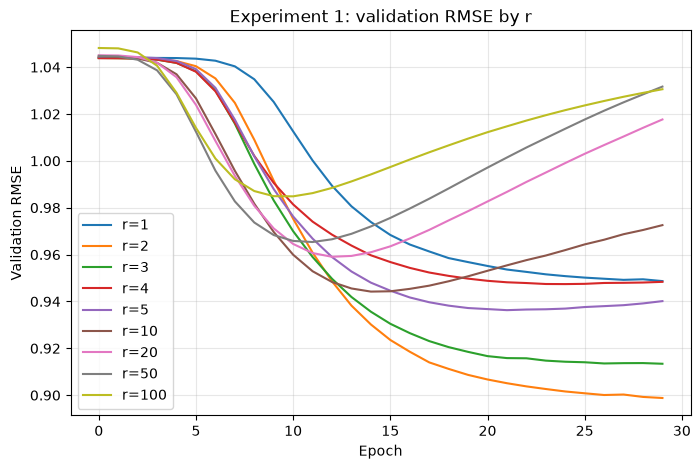

: 

In [ ]:
plt.figure(figsize=(8, 5))
for r in r_values:
    plt.plot(by_r[r][3], label=f"r={r}")
plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.title("Experiment 1: validation RMSE by r")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
print(f"{'r':>5} | {'val RMSE':>10} | {'train RMSE':>11}")
for r in r_values:
    _, _, train_hist, val_hist = by_r[r]
    print(f"{r:>5} | {val_hist[-1]:>10.4f} | {train_hist[-1]:>11.4f}")

    r |   val RMSE |  train RMSE
    1 |     0.9487 |      0.8582
    2 |     0.8988 |      0.7545
    3 |     0.9134 |      0.7296
    4 |     0.9484 |      0.7083
    5 |     0.9401 |      0.6767
   10 |     0.9726 |      0.5767
   20 |     1.0177 |      0.4529
   50 |     1.0317 |      0.2602
  100 |     1.0306 |      0.1396
